# **Loan Approval Classification for FinTrust Bank**
YBI Foundation — Data Analytics Internship Project

 ***Project Overview***

Project Title: Loan Approval Classification for FinTrust Bank

Problem Statement:

FinTrust Bank was manually processing loan applications which was a time-consuming and inconsistent process. The goal of this project is to build a Machine Learning model that can automatically predict whether a loan application should be Approved or Rejected based on the applicant's financial profile.

Objective:

To develop a binary classification model that accurately predict loan approval status using applicant data such as credit score, income, existing debts, and employment history.

Type of Problem: Binary Classification

Target Variable: Approval Status (Approved / Rejected)

Dataset Source: YBI Foundation GitHub Repository



**Step 1: Import Libraries**

Libraries are essential tools in Python that provide pre-built functions for data manipulation, visualization, and machine learning. We import pandas and numpy for data handling, matplotlib and seaborn for visualization, and sklearn for building and evaluating machine learning models.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


**Step 2: Load Dataset**

The dataset is loaded directly from YBI Foundation's GitHub repository using pandas read_csv(). We then examine its shape, data types, and check for missing values using df.isnull().sum(), info(), describe().

In [38]:

df = pd.read_csv("https://raw.githubusercontent.com/YBIFoundation/MLProjectIdeas/main/Loan%20Approval%20Classification%20for%20FinTrust%20Bank.csv")

df.head()

,Credit Score,Annual Income (₹),Existing Debts (₹),Employment History (Years),Loan Amount (₹),Loan Term (Months),Interest Rate (%),Approval Status
0,652,53022,8480,25,39199,12,10.92,Approved
1,699,54097,15629,17,21067,60,8.31,Approved
2,680,38886,4809,19,31048,48,7.50,Approved
3,794,36030,21006,23,38635,48,6.68,Approved
4,385,48314,21639,19,18231,12,8.87,Rejected


In [39]:
df.shape

(1000, 8)

In [40]:
df.isnull().sum()

,0
Credit Score,0
Annual Income (₹),0
Existing Debts (₹),0
Employment History (Years),0
Loan Amount (₹),0
Loan Term (Months),0
Interest Rate (%),0
Approval Status,0


In [41]:
df.describe()

,Credit Score,Annual Income (₹),Existing Debts (₹),Employment History (Years),Loan Amount (₹),Loan Term (Months),Interest Rate (%)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,575.885000,49576.438000,15140.314000,14.443000,25345.094000,36.540000,11.496130
std,157.354384,15309.160506,7727.756829,8.683095,14163.188351,16.940702,3.706084
min,300.000000,10000.000000,0.000000,0.000000,1060.000000,12.000000,5.020000
25%,437.750000,39314.750000,9901.000000,7.000000,13027.250000,24.000000,8.377500
50%,579.500000,49676.500000,15431.500000,15.000000,26071.000000,36.000000,11.600000
75%,708.500000,59731.500000,20319.500000,22.000000,37424.000000,48.000000,14.685000
max,849.000000,105227.000000,44605.000000,29.000000,49960.000000,60.000000,17.980000


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Credit Score                1000 non-null   int64  
 1   Annual Income (₹)           1000 non-null   int64  
 2   Existing Debts (₹)          1000 non-null   int64  
 3   Employment History (Years)  1000 non-null   int64  
 4   Loan Amount (₹)             1000 non-null   int64  
 5   Loan Term (Months)          1000 non-null   int64  
 6   Interest Rate (%)           1000 non-null   float64
 7   Approval Status             1000 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 62.6+ KB


**Step 3: EDA**

**3.1 Target Distribution**

We visualize the distribution of the target variable — Approval Status. Out of 1000 applications, 654 were Rejected and 346 were Approved, indicating a slightly imbalanced dataset.

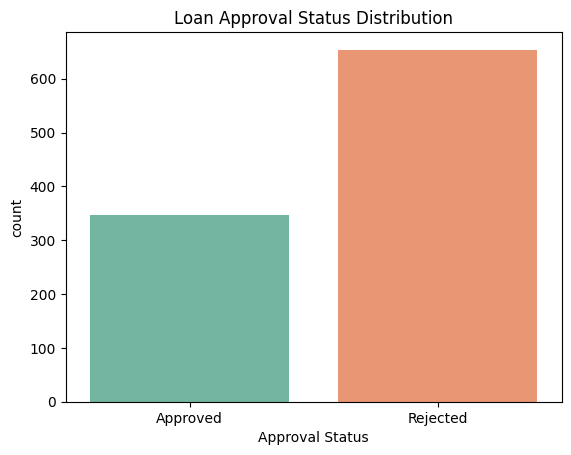

In [43]:
sns.countplot(x='Approval Status', data=df, palette='Set2')
plt.title('Loan Approval Status Distribution')
plt.show()

**3.2 Credit Score Distribution**

A histogram comparing Credit Scores of approved vs rejected applicants. Approved applicants have higher credit scores, confirming that credit score is a key factor in loan approval decisions.

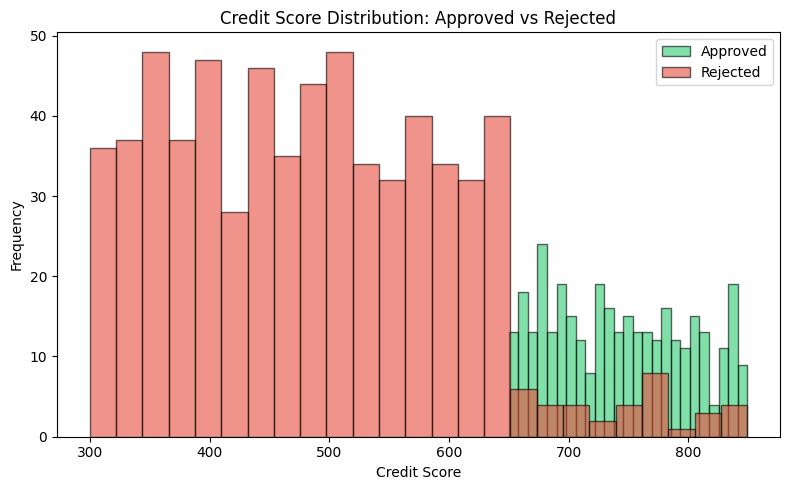

Avg Credit Score - Approved: 742.8
Avg Credit Score - Rejected: 487.6


In [44]:
plt.figure(figsize=(8,5))
approved = df[df['Approval Status']=='Approved']['Credit Score']
rejected = df[df['Approval Status']=='Rejected']['Credit Score']

plt.hist(approved, bins=25, alpha=0.6, label='Approved', color='#2ecc71', edgecolor='black')
plt.hist(rejected, bins=25, alpha=0.6, label='Rejected', color='#e74c3c', edgecolor='black')
plt.title('Credit Score Distribution: Approved vs Rejected')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Avg Credit Score - Approved: {approved.mean():.1f}")
print(f"Avg Credit Score - Rejected: {rejected.mean():.1f}")

**3.3 Boxplots**

Boxplots display the distribution of all numerical features against Approval Status. Approved applicants generally show higher annual income, lower debts, and longer employment history compared to rejected applicants.

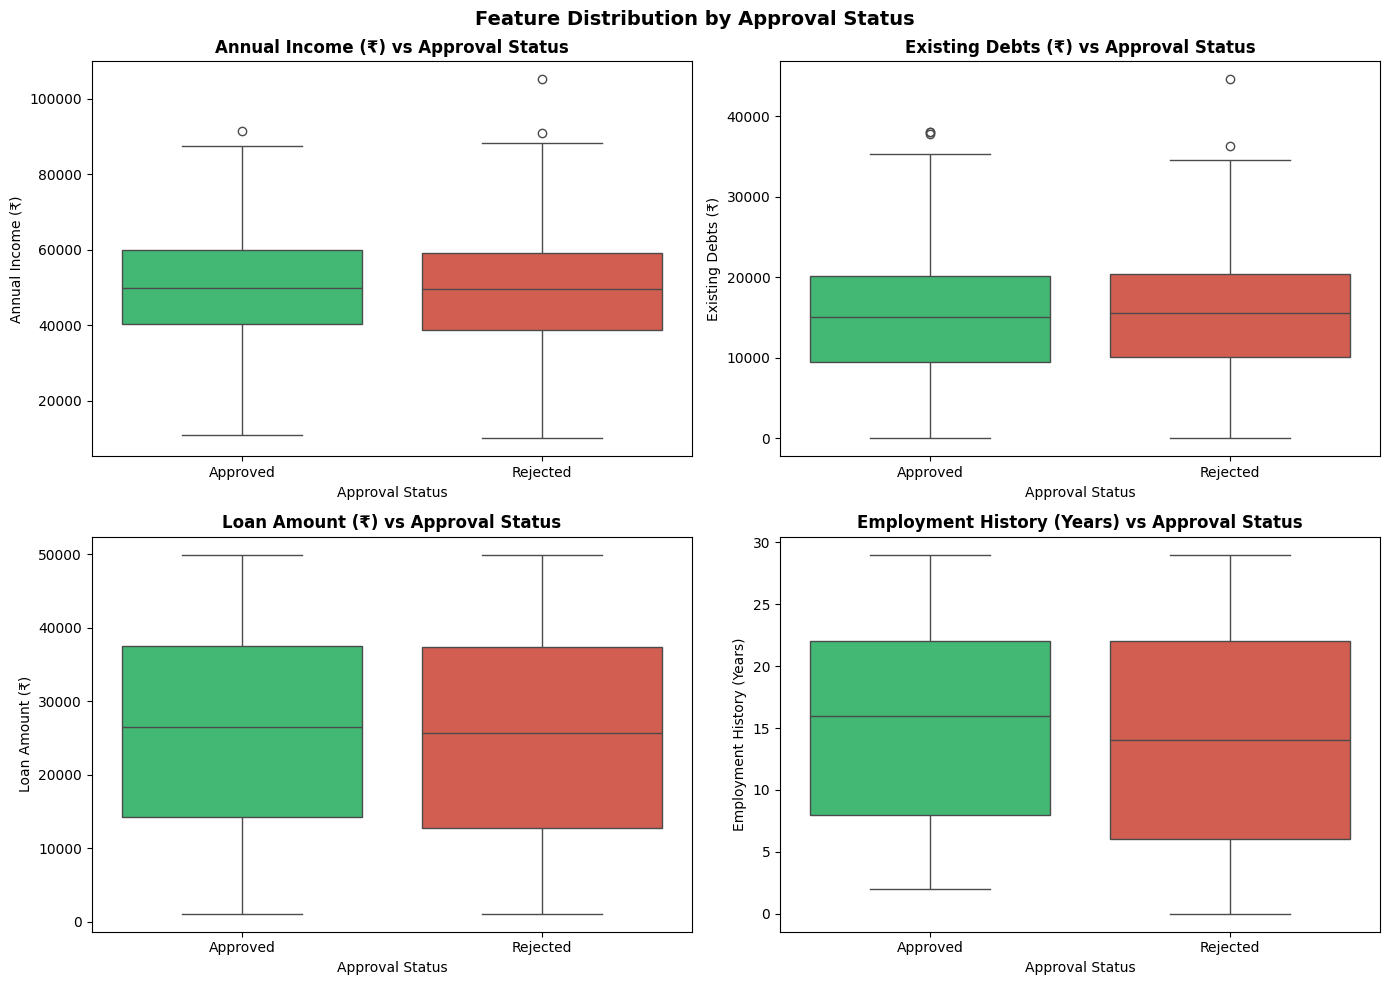

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

features = ['Annual Income (₹)', 'Existing Debts (₹)',
            'Loan Amount (₹)', 'Employment History (Years)']

for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(x='Approval Status', y=feat, data=df,
                palette={'Approved':'#2ecc71','Rejected':'#e74c3c'}, ax=ax)
    ax.set_title(f'{feat} vs Approval Status', fontweight='bold')

plt.suptitle('Feature Distribution by Approval Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**3.4 Correlation Heatmap**

A heatmap showing the correlation between all numerical features including the target variable. Credit Score shows the strongest positive correlation with Approval Status, while Debts and Interest Rate show negative correlation.

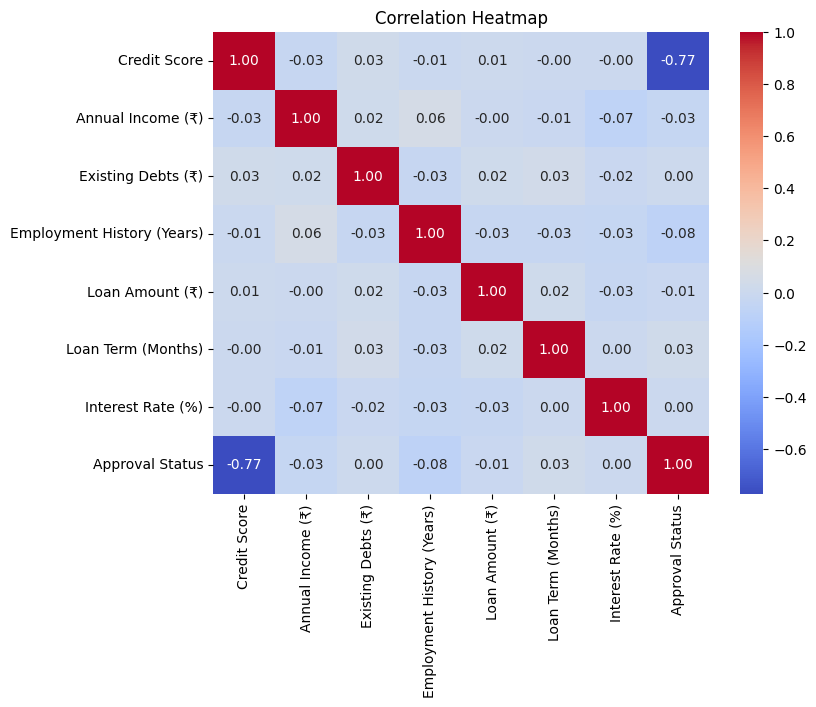

In [28]:
temp = df.copy()
temp['Approval Status'] = LabelEncoder().fit_transform(temp['Approval Status'])

plt.figure(figsize=(8,6))
sns.heatmap(temp.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Step 4: Preprocessing**

The target column Approval Status is encoded using LabelEncoder — converting Approved and Rejected into numerical values.

 Features (X) and target (y) are separated.

 Data is split into 80% training and 20% testing sets.

 StandardScaler is applied to normalize all features to the same scale, which is important because features like Credit Score and Annual Income have very different ranges.



In [29]:
le = LabelEncoder()
df['Approval Status'] = le.fit_transform(df['Approval Status'])

X = df.drop(columns=['Approval Status'])
y = df['Approval Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

**Step 5: Model Building**

*Logistic Regression:*  it is a  classification algorithm that calculate the probability of loan approval using a sigmoid function.

*Random Forest:* it is an ensemble method that combine 100 decision trees. Each tree is trained on a different subset of data and the final prediction is given by majority voting.

In [30]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

**Step 6: Evaluation**

**Classification Report** provides precision, recall, and F1-score for both classes. Logistic Regression achieved 94% accuracy while Random Forest achieved 99% accuracy because dataset is synthetic, real-world performance may vary.


In [31]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

print("==== Logistic Regression ====")
print(classification_report(y_test, y_pred_lr, target_names=['Approved','Rejected']))

print("==== Random Forest ====")
print(classification_report(y_test, y_pred_rf, target_names=['Approved','Rejected']))

==== Logistic Regression ====
              precision    recall  f1-score   support

    Approved       0.87      0.97      0.92        69
    Rejected       0.98      0.92      0.95       131

    accuracy                           0.94       200
   macro avg       0.93      0.95      0.94       200
weighted avg       0.94      0.94      0.94       200

==== Random Forest ====
              precision    recall  f1-score   support

    Approved       1.00      0.99      0.99        69
    Rejected       0.99      1.00      1.00       131

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



**Confusion Matrix** shows the breakdown of correct and incorrect predictions — True Positives, True Negatives, False Positives, and False Negatives — giving a clear picture of where the model makes errors.

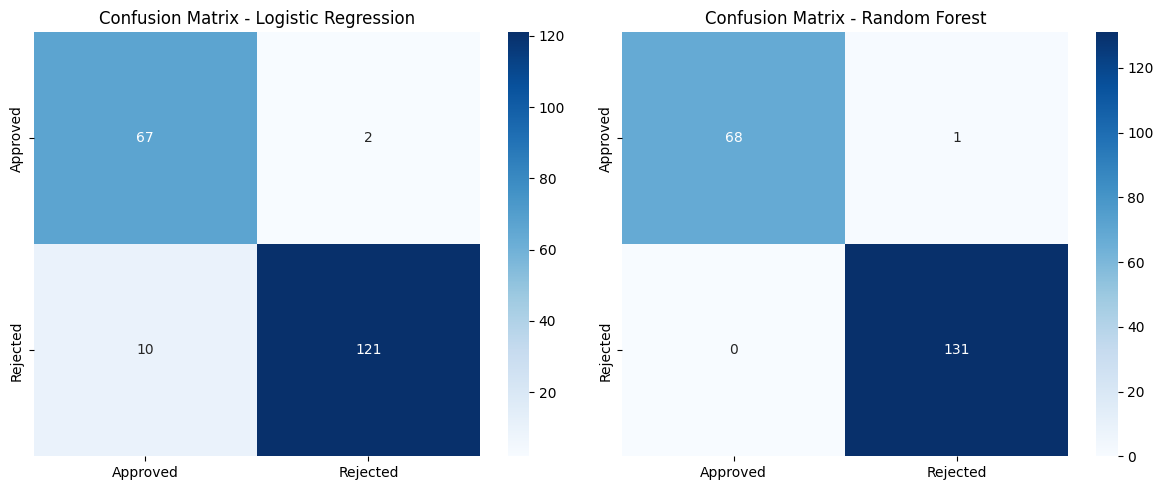

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_rf], ['Logistic Regression','Random Forest']):
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['Approved','Rejected'],
                yticklabels=['Approved','Rejected'], ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
plt.tight_layout()
plt.show()

# **Model Comparison**

After evaluating both models on the test dataset of 200 samples, Random Forest outperformed Logistic Regression over all performance metrics.

**Logistic Regression**achieved an overall accuracy of 94% which works well when the relationship between features and target is linear. However it made 12 incorrect predictions in total — 10 false approvals and 2 false rejections — which is a significant concern in a banking environment.

**Random Forest**achieved 99% accuracy with only 1 incorrect prediction across the entire test set. it was able to capture complex non-linear patterns in the data that Logistic Regression could not.

From a business perspective, Random Forest is the best choice for FinTrust Bank. In loan approval systems the cost of a wrong decision is very high — approving a wrong person leads to direct financial loss while rejecting an eligible applicant means lost business.


**in conclusion**,while Logistic Regression serves as a good baseline and explainable model, Random Forest is the recommended final model for FinTrust Bank's automated loan approval system due to its superior accuracy, and minimun error rate.

**ROC Curve Analysis**

 Logistic Regression achieved AUC of 0.9798 which is excellent. Random Forest achieved a perfect AUC of 1.0000, meaning it perfectly separated all classes without any error. The closer the curve is to the top-left corner, the better the model.

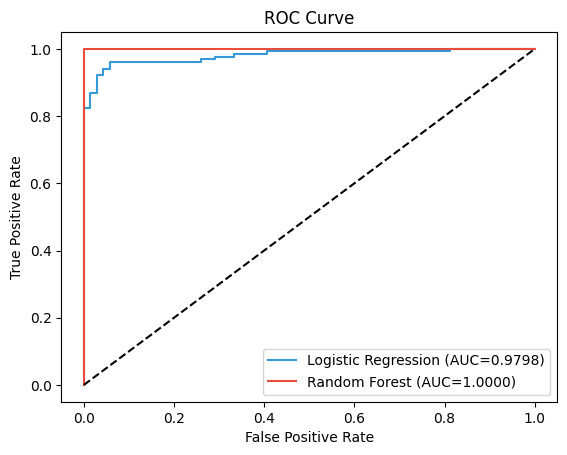

In [33]:
for y_prob, name, color in [(y_prob_lr,'Logistic Regression','#3498db'),
                              (y_prob_rf,'Random Forest','#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.4f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Feature Importance**

Feature Importance shows which features contributed most to the Random Forest model's predictions.
 Credit Score with an score of 0.84, contributing 84% to the decision making. Employment History came second at 0.07, while all other features had minimim contribution. This confirms that Credit Score is the single most critical factor in predicting loan approval for FinTrust Bank.

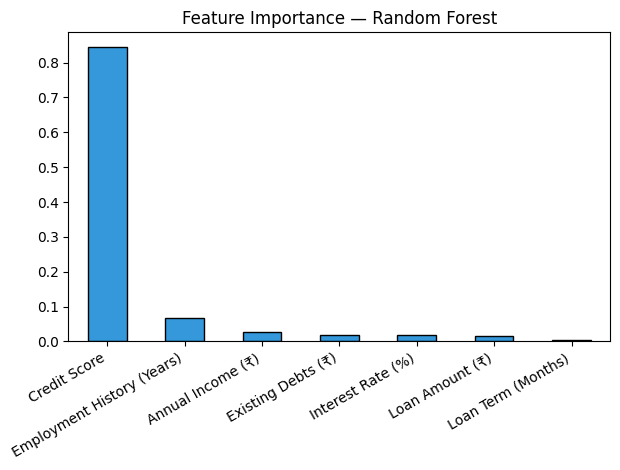

In [34]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

***Live Prediction Testing***

To validate the model in a real-world scenario, two test cases were created manually and passed through the trained Random Forest model.

In [35]:
import numpy as np

new_data = pd.DataFrame({
    'Credit Score': [750],
    'Annual Income (₹)': [60000],
    'Existing Debts (₹)': [5000],
    'Employment History (Years)': [5],
    'Loan Amount (₹)': [20000],
    'Loan Term (Months)': [24],
    'Interest Rate (%)': [8.5]
})

new_data_scaled = scaler.transform(new_data)

# Predict
pred = rf_model.predict(new_data_scaled)
prob = rf_model.predict_proba(new_data_scaled)

print(f"Prediction: {'Approved ✅' if pred[0] == 0 else 'Rejected ❌'}")
print(f"Approval Probability: {prob[0][0]*100:.2f}%")
print(f"Rejection Probability: {prob[0][1]*100:.2f}%")

Prediction: Approved ✅
Approval Probability: 99.00%
Rejection Probability: 1.00%


**Test Case 1 — Approved**

A strong applicant profile with high Credit Score of 750, stable Annual Income of ₹60,000, low  Debt of ₹5,000, 5 years of Employment History, and a reasonable Loan Amount of ₹20,000. The model predicted Approved with 99% confidence, which aligns with the expected outcome for such a financially stable profile.

In [36]:
new_data = pd.DataFrame({
    'Credit Score': [350],
    'Annual Income (₹)': [15000],
    'Existing Debts (₹)': [20000],
    'Employment History (Years)': [1],
    'Loan Amount (₹)': [50000],
    'Loan Term (Months)': [12],
    'Interest Rate (%)': [15.0]
})
new_data_scaled = scaler.transform(new_data)

# Predict
pred = rf_model.predict(new_data_scaled)
prob = rf_model.predict_proba(new_data_scaled)

print(f"Prediction: {'Approved ✅' if pred[0] == 0 else 'Rejected ❌'}")
print(f"Approval Probability: {prob[0][0]*100:.2f}%")
print(f"Rejection Probability: {prob[0][1]*100:.2f}%")

Prediction: Rejected ❌
Approval Probability: 2.00%
Rejection Probability: 98.00%


**Test Case 2 — Rejected**

A weak applicant profile with very low Credit Score of 350, low Annual Income of ₹15,000, high Debt of ₹20,000 which exceeds the income, only 1 year of Employment History, and a high Loan Amount of ₹50,000. The model predicted Rejected with 98% confidence, correctly identifying this as a high-risk application.

# **Conclusion**

-The project successfully built a Loan Approval Prediction system for FinTrust Bank.

-Random Forest outperformed Logistic Regression with 99% accuracy.

-The dataset was split into 80% training and 20% testing data to ensure correct model evaluation.

-Credit Score is a most important feature.

-The model can help the bank automate loan decisions, reduce processing time, and ensure consistent and unbiased approvals.